In [ ]:
"""
Ufuncs previously used were for same sized arrays i.e for a+b, a and b both have to be of same size. 
Broadcasting allows these types of binary operations to be perfomred on arrays of differnece sizes. For example: adding a scalar to an array a+5
"""

In [4]:
import numpy as np

In [ ]:
#Eg:1

In [9]:
a = np.arange(1,6)
a

array([1, 2, 3, 4, 5])

In [11]:
a + 5        #we can think of this scalar value 5 to stretch/broadcast into an array [5,5,5]

array([ 6,  7,  8,  9, 10])

In [ ]:
#Eg:2

In [12]:
M = np.ones((3,3), dtype = int)
M

array([[1, 1, 1],
       [1, 1, 1],
       [1, 1, 1]])

In [13]:
a = [0,1,2]

In [15]:
M + a   #a is broadcasted to 2d array

array([[1, 2, 3],
       [1, 2, 3],
       [1, 2, 3]])

In [ ]:
#Eg:3  Both arrays broadcasted 

In [17]:
a = np.arange(3)
b = np.arange(3)[:,np.newaxis]

print(a)
print(b)

[0 1 2]
[[0]
 [1]
 [2]]


In [19]:
a + b    #3x1 array and 1x3 array are broadcasted to 3x3 array (to a common shape)

array([[0, 1, 2],
       [1, 2, 3],
       [2, 3, 4]])

In [ ]:
"""
Rules of Broadcasting:
1. Difference in dimensions: If one array has fewer dimensions, NumPy adds or 'pads' 1s to the left of its shape. (Eg (4,) would be broadcasted to (1,4))
2. Difference in shape: If one array has 1 in a dimension and the other has a larger size, the size 1 is stretched/repeated to match.
3. Difference in sizes of shapes AND neither shape has size = 1: Error is raised, no broadcasting
"""

In [ ]:
#Example 1:

In [22]:
M = np.ones((2,3)) #shape -> (2,3)

In [23]:
a = np.arange(3)  #shape -> (3,)

In [ ]:
#Broadcasting flow: By rule 1, lesser dimension array is left padded with 1s i.e a.shape = (1,3). By rule 2, dimension having size = 1 is stretched so a.shape = (2,3)
# M = [[1,1,1], [1,1,1]] and a = [[1,2,3],[1,2,3]]

In [ ]:
#Example 2:

In [29]:
a = np.arange(3).reshape((3,1))    #shape = (3,1)
b = np.arange(3)                   #shape = (3,)
print(a)
print(b)

[[0]
 [1]
 [2]]
[0 1 2]


In [ ]:
#Broadcasting flow: By rule 1, lesser dimension array is left padded with 1s i.e b.shape = (1,3). By rule 2, dimension(s) having size = 1 is stretched so b.shape = (3,3) and a.shape = (3,3)

In [ ]:
#Example 3:

In [31]:
a = np.ones((3,2))    #shape = (3,2)
b = np.arange(3)                   #shape = (3,)
print(a)
print(b)

[[1. 1.]
 [1. 1.]
 [1. 1.]]
[0 1 2]


In [33]:
#Even after applying broadcasting rules 1 and 2, the dimension sizes do not match hence error:
print(a.shape)
print(b.shape)

(3, 2)
(3,)


In [34]:
a + b

ValueError: operands could not be broadcast together with shapes (3,2) (3,) 

In [ ]:
#Applications of Broadcasting

In [38]:
#1. Centering an Array (subtracting row-wise mean from array)
rng = np.random.default_rng(seed=1701)
X = rng.random((10,3))

Xmean = X.mean(0)       #which is same as Xmean = np.mean(X, axis = 0) //mean of each column
Xmean

array([0.38503638, 0.36991443, 0.63896043])

In [41]:
Xcentered = X - Xmean    #centered array

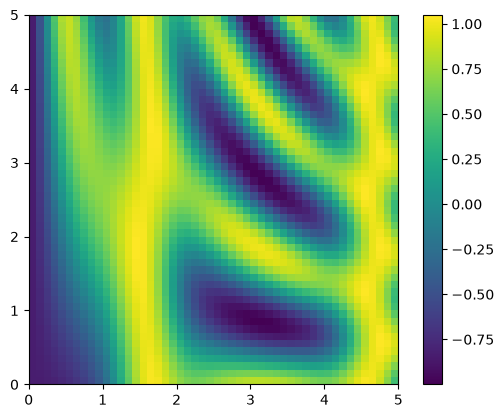

In [40]:
#2. Plotting a 2d function
x = np.linspace(0, 5, 50)
y = np.linspace(0, 5, 50)[:, np.newaxis]

z = np.sin(x) ** 10 + np.cos(10 + y * x) * np.cos(x)

%matplotlib inline
import matplotlib.pyplot as plt
plt.imshow(z, origin='lower', extent=[0, 5, 0, 5])
plt.colorbar();